<a href="https://colab.research.google.com/github/Vladislav-spect/DeepLearningSchool/blob/main/%22Feature_engineering_ipynb%22%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Кредитный скоринг

В этом ноутбуке мы разберем некоторые темы feature engineering на примере датасета для задачи кредитного скоринга.

Для этой задачи есть [учебное соревнование на Kaggle](https://www.kaggle.com/competitions/bank-issues-042022/leaderboard). Вы можете отправлять в него свои решения.

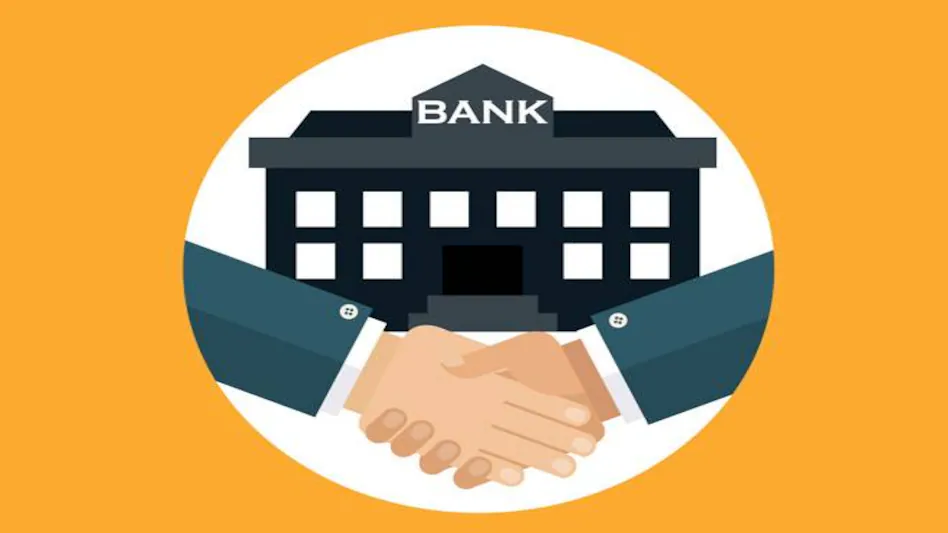

## Скачивание данных

Скачаем данные и импортируем нужные библиотеки

In [ ]:
! pip install wldhx.yadisk-direct
! curl -L $(yadisk-direct https://disk.yandex.com/d/sknuSa3xoNBsDw) -o bank-issues-data.zip

ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [ ]:
! unzip -qq bank-issues-data.zip

replace __MACOSX/._bank-issues-data? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Обработка тренировочных данных

In [ ]:
train_data = pd.read_csv('/content/bank-issues-data/train.csv')
test_data = pd.read_csv('/content/bank-issues-data/test.csv')


In [ ]:
train_data.head()

,client_id,gender,age,marital_status,job_position,credit_sum,credit_month,tariff_id,score_shk,education,living_region,monthly_income,credit_count,overdue_credit_count,open_account_flg
0,1,M,25,UNM,SPC,26389.0,10,1.32,0.584105,SCH,ОБЛ КУРСКАЯ,35000.0,2.0,0.0,1
1,2,F,37,MAR,SPC,19588.0,12,1.43,0.718935,SCH,РЕСПУБЛИКА ТАТАРСТАН,15000.0,0.0,0.0,1
2,3,F,28,UNM,SPC,53669.0,18,1.10,0.586015,GRD,МОСКВА Г,70000.0,4.0,0.0,1
3,4,M,34,MAR,SPC,26349.0,10,1.43,0.655703,SCH,СВЕРДЛОВСКАЯ ОБЛАСТЬ,42500.0,4.0,0.0,0
4,5,F,43,MAR,UMN,11589.0,10,1.10,0.271893,GRD,РЯЗАНСКАЯ ОБЛАСТЬ,20000.0,3.0,0.0,0


Поля данных:
- **client_id** — Уникальный идентификатор клиента
- **gender** — Пол
- **age** — Возраст (в годах)
- **marital_status** — Семейное положение.
    Возможные значения:
    - UNM : Холост/не замужем
    - DIV : Резведен (а)
    - MAR : Женат/замужем
    - WID : Вдовец, вдова
    - CIV : Гражданский брак
- **job_position** — Работа.
    Возможные значения:
    - SPC : Неруководящий сотрудник - специалист
    - DIR : Руководитель организации
    - HSK : Домохозяйка
    - WOI : Работает на ИП
    - WRK : Неруководящий сотрудник - рабочий
    - ATP : Неруководящий сотрудник - обслуживающий персонал
    - WRP : Работающий пенсионер
    - UMN : Руководитель подразделения
    - NOR : Не работает
    - NS : Пенсионер
    - BIS : Собственный бизнес
    - INP : Индивидуальный предприниматель
- **credit_sum** — Сумма кредита
- **credit_month** — Срок кредитования в месяцах
- **tariff_id** — Номер предлагаемого тарифа
- **education** — Тип образования.
    Возможные знаяения:
    - SCH : Начальное, среднее
    - PGR : Второе высшее
    - GRD : Высшее
    - UGR : Неполное высшее
    - ACD : Ученая степень
- **living_region** — Регион проживания
- **monthly_income** — Зарплата в месяц
- **credit_count** — Количество кредитов у клиента
- **overdue_credit_count** — Количество просроченных кредитов клиента
- **open_account_flag** — Целевая переменная -- выберет клиент наш банк или нет

Отделим целевую переменную от признаков:

In [ ]:
y_train = train_data['open_account_flg']
train_data = train_data.drop(columns=['open_account_flg'])

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119518 entries, 0 to 119517
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   client_id             119518 non-null  int64  
 1   gender                119518 non-null  object 
 2   age                   119518 non-null  int64  
 3   marital_status        119518 non-null  object 
 4   job_position          119518 non-null  object 
 5   credit_sum            119518 non-null  float64
 6   credit_month          119518 non-null  int64  
 7   tariff_id             119518 non-null  float64
 8   score_shk             119518 non-null  float64
 9   education             119518 non-null  object 
 10  living_region         119385 non-null  object 
 11  monthly_income        119518 non-null  float64
 12  credit_count          113032 non-null  float64
 13  overdue_credit_count  113032 non-null  float64
dtypes: float64(6), int64(3), object(5)
memory usage: 12.

### Заполнение пропусков

Еще раз выведем то, как выглядят тренировочные данные для удобства

In [ ]:
train_data.head()

,client_id,gender,age,marital_status,job_position,credit_sum,credit_month,tariff_id,score_shk,education,living_region,monthly_income,credit_count,overdue_credit_count
0,1,M,25,UNM,SPC,26389.0,10,1.32,0.584105,SCH,ОБЛ КУРСКАЯ,35000.0,2.0,0.0
1,2,F,37,MAR,SPC,19588.0,12,1.43,0.718935,SCH,РЕСПУБЛИКА ТАТАРСТАН,15000.0,0.0,0.0
2,3,F,28,UNM,SPC,53669.0,18,1.10,0.586015,GRD,МОСКВА Г,70000.0,4.0,0.0
3,4,M,34,MAR,SPC,26349.0,10,1.43,0.655703,SCH,СВЕРДЛОВСКАЯ ОБЛАСТЬ,42500.0,4.0,0.0
4,5,F,43,MAR,UMN,11589.0,10,1.10,0.271893,GRD,РЯЗАНСКАЯ ОБЛАСТЬ,20000.0,3.0,0.0


Посмотрим, в каких колонках есть пропуски в тренировочных данных

In [ ]:
train_data.isna().any()

,0
client_id,False
gender,False
age,False
marital_status,False
job_position,False
credit_sum,False
credit_month,False
tariff_id,False
score_shk,False
education,False


Посмотрим также, какие пропуски есть в тестовых данных:

In [ ]:
test_data.isna().any()

,0
client_id,False
gender,False
age,False
marital_status,False
job_position,False
credit_sum,False
credit_month,False
tariff_id,False
score_shk,False
education,False


Видим, что в тестовой части есть пропуски в колонке monthly_income, а в тренировочной части в ней пропусков нет. Нам нужно будет понять, как мы будем заполнять пропуски в этой колонке.

**Внимание**: важно помнить, что иногда в данных бывают пропуски, которые pandas не ловит. Например, когда пропуск в категориальной колонке "job_position", и выражается он тем, что вместо значения стоит пустая строка '' или пробел ' '. Такое pandas не отловит.

**Как можно заполнять пропуски в колонках?**



#### Варианты заполнения пропусков

- Заполнить пропуски некоторой статистикой по данным (среднее/медиана/0/...). Поможет [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html#sklearn.impute.SimpleImputer) из Sklearn;

    **Вопрос**: почему медиана предпочтительнее среднего?
Среднее на себя тянут выбросы, у медианы такого нет
- Использовать более сложные стратегии. Например, [IterativeImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html#sklearn.impute.IterativeImputer) или  [KNNImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html);

- Добавить значение "пропуск" на место пропусков. Поможет [MissingIndicator](https://scikit-learn.org/stable/modules/generated/sklearn.impute.MissingIndicator.html#sklearn.impute.MissingIndicator) из Sklearn;
- А иногда вообще бывает так, что из тренировочных данных лучше удалить строки, где много пропусков. Логика такая: если об объекте известно мало, то полезной информации для модели этот объект не несет. Обратите внимание, что из тестовых данных никакие строки удалять нельзя!
- Вообще удалить признак с пропусками. Может быть логично, если пропусков слишком много;

#### Заполнение пропусков в наших данных

Посмотрим, сколько пропущенных значений в колонках credit_count и overdue_credit_count:

In [ ]:
train_data['credit_count'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 119518 entries, 0 to 119517
Series name: credit_count
Non-Null Count   Dtype  
--------------   -----  
113032 non-null  float64
dtypes: float64(1)
memory usage: 933.9 KB


In [ ]:
np.unique(train_data['credit_count'], return_counts=True)

(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., nan]),
 array([18219, 31714, 25799, 16707,  9826,  5285,  2760,  1345,   707,
          326,   141,    90,    56,    25,    12,    10,     2,     4,
            1,     3,  6486]))

Заполним пропуск в credit_count медианой:

In [ ]:
# заполнение пропусков статистикой вручную

# median_value_credit_count = np.median(train_data['credit_count'].dropna())
# train_data['credit_count'].fillna(median_value_credit_count)

In [ ]:
from sklearn.impute import SimpleImputer

simple_imputer = SimpleImputer(missing_values=np.nan, strategy='median')
simple_imputer.fit(train_data[['credit_count']])
train_data['credit_count'] = simple_imputer.transform(train_data[['credit_count']])

In [ ]:
train_data['credit_count'].isna().any()

np.False_

Заполним пропуск в overdue_credit_count с помощью KNNImputer:

In [ ]:
train_data['job_position'].dtype #если тип Object, то выдается '0'

dtype('O')

In [ ]:
numeric_columns = [column for column in train_data.columns if train_data[column].dtype != 'O'] #все числовые столбцы
numeric_columns.remove('client_id')
numeric_columns

['age',
 'credit_sum',
 'credit_month',
 'tariff_id',
 'score_shk',
 'monthly_income',
 'credit_count',
 'overdue_credit_count']

In [ ]:
len(numeric_columns)

8

В идеале сначала категориальные перевести в числовые и заполнять пропуски по ним, чтобы категориальные переменные тоже учитывались

In [ ]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=3)
knn_imputer.fit(train_data[numeric_columns]) #Все числовые признаки
transformed_overdue_credit_count = knn_imputer.transform(train_data[numeric_columns])[:, 7] #берем именно 8-ую колонку для overdue credit count
train_data['overdue_credit_count'] = transformed_overdue_credit_count

In [ ]:
train_data['overdue_credit_count'].isna().any()

np.False_

для mountly income


In [ ]:
transformed_monthly_income = knn_imputer.transform(train_data[numeric_columns])[:, 5] #берем именно 6-ую колонку для overdue credit count
train_data['monthly_income'] = transformed_monthly_income

### Обработка категориальных признаков

In [ ]:
train_data.head()

,client_id,gender,age,marital_status,job_position,credit_sum,credit_month,tariff_id,score_shk,education,living_region,monthly_income,credit_count,overdue_credit_count
0,1,M,25,UNM,SPC,26389.0,10,1.32,0.584105,SCH,ОБЛ КУРСКАЯ,35000.0,2.0,0.0
1,2,F,37,MAR,SPC,19588.0,12,1.43,0.718935,SCH,РЕСПУБЛИКА ТАТАРСТАН,15000.0,0.0,0.0
2,3,F,28,UNM,SPC,53669.0,18,1.10,0.586015,GRD,МОСКВА Г,70000.0,4.0,0.0
3,4,M,34,MAR,SPC,26349.0,10,1.43,0.655703,SCH,СВЕРДЛОВСКАЯ ОБЛАСТЬ,42500.0,4.0,0.0
4,5,F,43,MAR,UMN,11589.0,10,1.10,0.271893,GRD,РЯЗАНСКАЯ ОБЛАСТЬ,20000.0,3.0,0.0


In [ ]:
categorical_columns = [column for column in train_data.columns if train_data[column].dtype == 'O']
categorical_columns

['gender', 'marital_status', 'job_position', 'education', 'living_region']

In [ ]:
categorical_columns = categorical_columns + ['tariff_id']

In [ ]:
categorical_columns = [x for x in categorical_columns if x != 'living_region'] #обработаем позже

In [ ]:
np.unique(train_data['marital_status'])

array(['CIV', 'DIV', 'MAR', 'UNM', 'WID'], dtype=object)

Лучше не делать CIV = 1 DIV = 2 MAR = 3 и тд. Потому что модель будет сравнивать эти значения, это неправильно, мы так задаем порядок, которого нет. Это laber encoing. Лучше использовать One-Hot

#### One-hot кодирование

Лучше не использовать pandas, тк может произойти ситуация, когда у нас в выборке трейна есть UNM и следовательно в таблице он появиться, а в тестовой выборке никого нет с UNM, тогда будет 4 признака. Те на трейн дате 5 признаков, а на тестовой 4, надо будет в ручную добавлять UNM, что не очень удобно. Поэтому лучше sklearn

In [ ]:
# dummy_features = pd.get_dummies(train_data['marital_status'])
# dummy_features.head()

One-hot кодирование с помощью OneHotEncoder из Sklearn

In [ ]:
categorical_columns

['gender', 'marital_status', 'job_position', 'education', 'tariff_id']

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='if_binary', sparse_output=False) #if binary - если в колонке всего 2 уникальных значения
#то создаться всего 1 признак с 0 и 1
ohe.fit(train_data[categorical_columns])
new_category_columns = ohe.transform(train_data[categorical_columns])

In [ ]:
new_category_columns

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [ ]:
ohe.get_feature_names_out()

array(['gender_M', 'marital_status_CIV', 'marital_status_DIV',
       'marital_status_MAR', 'marital_status_UNM', 'marital_status_WID',
       'job_position_ATP', 'job_position_BIS', 'job_position_BIU',
       'job_position_DIR', 'job_position_HSK', 'job_position_INP',
       'job_position_NOR', 'job_position_PNA', 'job_position_PNI',
       'job_position_PNS', 'job_position_PNV', 'job_position_SPC',
       'job_position_UMN', 'job_position_WOI', 'job_position_WRK',
       'job_position_WRP', 'education_ACD', 'education_GRD',
       'education_PGR', 'education_SCH', 'education_UGR', 'tariff_id_1.0',
       'tariff_id_1.1', 'tariff_id_1.16', 'tariff_id_1.17',
       'tariff_id_1.18', 'tariff_id_1.19', 'tariff_id_1.2',
       'tariff_id_1.21', 'tariff_id_1.22', 'tariff_id_1.23',
       'tariff_id_1.24', 'tariff_id_1.25', 'tariff_id_1.26',
       'tariff_id_1.27', 'tariff_id_1.28', 'tariff_id_1.29',
       'tariff_id_1.3', 'tariff_id_1.32', 'tariff_id_1.4',
       'tariff_id_1.41', 'tarif

In [ ]:
new_train_columns = pd.DataFrame(new_category_columns, columns=ohe.get_feature_names_out()) #в скобках (значения, название)
train_data = train_data.drop(columns=categorical_columns)
train_data = pd.concat([train_data, new_train_columns], axis=1) #axis = 1, те по столбцам объединение а не по строкам
train_data.head()

,client_id,age,credit_sum,credit_month,score_shk,living_region,monthly_income,credit_count,overdue_credit_count,gender_M,...,tariff_id_1.48,tariff_id_1.5,tariff_id_1.52,tariff_id_1.56,tariff_id_1.6,tariff_id_1.7,tariff_id_1.9,tariff_id_1.91,tariff_id_1.94,tariff_id_1.96
0,1,25,26389.0,10,0.584105,ОБЛ КУРСКАЯ,35000.0,2.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,37,19588.0,12,0.718935,РЕСПУБЛИКА ТАТАРСТАН,15000.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,28,53669.0,18,0.586015,МОСКВА Г,70000.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,34,26349.0,10,0.655703,СВЕРДЛОВСКАЯ ОБЛАСТЬ,42500.0,4.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,43,11589.0,10,0.271893,РЯЗАНСКАЯ ОБЛАСТЬ,20000.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Если мы обучили модель машинного обучения на каких-то признаках(столбцах), то эти же признаки должны остаться и в основной модели(тестовая выборка). Если же мы обучили нашу модель по 4 признакам, например, CIV	DIV	MAR	UNM (см выше), а признак WID появился только в тестовых данных, то мы ничего с этим сделать не сможем и просто везде будут 0.

#### Обработка living_region

In [ ]:
train_data['living_region'] = train_data['living_region'].fillna("НЕТ РЕГИОНА")

In [ ]:
np.unique(train_data['living_region'], return_counts=True)

(array(['74', '98', 'АДЫГЕЯ РЕСП', 'АЛТАЙСКИЙ', 'АЛТАЙСКИЙ КРАЙ',
        'АМУРСКАЯ ОБЛ', 'АМУРСКАЯ ОБЛАСТЬ', 'АО НЕНЕЦКИЙ',
        'АО ХАНТЫ-МАНСИЙСКИЙ АВТОНОМНЫЙ ОКРУГ - Ю', 'АО ЯМАЛО-НЕНЕЦКИЙ',
        'АОБЛ ЕВРЕЙСКАЯ', 'АРХАНГЕЛЬСКАЯ', 'АРХАНГЕЛЬСКАЯ ОБЛ',
        'АРХАНГЕЛЬСКАЯ ОБЛАСТЬ', 'АСТРАХАНСКАЯ', 'АСТРАХАНСКАЯ ОБЛ',
        'АСТРАХАНСКАЯ ОБЛАСТЬ', 'БАШКОРТОСТАН', 'БАШКОРТОСТАН РЕСП',
        'БЕЛГОРОДСКАЯ ОБЛ', 'БЕЛГОРОДСКАЯ ОБЛАСТЬ', 'БРЯНСКАЯ ОБЛ',
        'БРЯНСКАЯ ОБЛАСТЬ', 'БРЯНСКИЙ', 'БУРЯТИЯ', 'БУРЯТИЯ РЕСП',
        'ВЛАДИМИРСКАЯ ОБЛ', 'ВЛАДИМИРСКАЯ ОБЛАСТЬ', 'ВОЛГОГРАДСКАЯ ОБЛ',
        'ВОЛГОГРАДСКАЯ ОБЛАСТЬ', 'ВОЛОГОДСКАЯ', 'ВОЛОГОДСКАЯ ОБЛ',
        'ВОЛОГОДСКАЯ ОБЛ.', 'ВОЛОГОДСКАЯ ОБЛАСТЬ', 'ВОРОНЕЖСКАЯ ОБЛ',
        'ВОРОНЕЖСКАЯ ОБЛАСТЬ', 'Г МОСКВА', 'Г. МОСКВА',
        'Г. САНКТ-ПЕТЕРБУРГ', 'Г.МОСКВА', 'ГОРЬКОВСКАЯ ОБЛ',
        'ГУСЬ-ХРУСТАЛЬНЫЙ Р-Н', 'ДАГЕСТАН РЕСП', 'ЕВРЕЙСКАЯ АВТОНОМНАЯ',
        'ЕВРЕЙСКАЯ АОБЛ', 'ЗАБАЙКАЛЬСКИЙ КРАЙ', 'ИВАНОВСКАЯ ОБЛ',

In [ ]:
import re

def normalize_region(name):
    if not isinstance(name, str) or not name.strip():
        return None

    # 1️⃣ Приведение регистра и очистка
    name = name.upper()
    name = re.sub(r'[.,()/-]', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()

    # 2️⃣ Замена сокращений в любом месте
    name = re.sub(r'\bРЕСП\b', 'РЕСПУБЛИКА', name)
    name = re.sub(r'\bОБЛ\b', 'ОБЛАСТЬ', name)
    name = re.sub(r'\bАОБЛ\b', 'АВТОНОМНАЯ ОБЛАСТЬ', name)
    name = re.sub(r'\bАО\b', 'АВТОНОМНЫЙ ОКРУГ', name)
    name = re.sub(r'\bКРАЙ\b', 'КРАЙ', name)
    name = re.sub(r'\bГ\b', 'ГОРОД', name)

    # 3️⃣ Приведение конкретных случаев
    mapping = {
        'ГОРОД МОСКВА': 'МОСКВА',
        'МОСКВА Г': 'МОСКВА',
        'Г МОСКВА': 'МОСКВА',
        'Г САНКТ ПЕТЕРБУРГ': 'САНКТ-ПЕТЕРБУРГ',
        'ГОРОД САНКТ ПЕТЕРБУРГ': 'САНКТ-ПЕТЕРБУРГ',
        'РЕСПУБЛИКА САХА ЯКУТИЯ': 'РЕСПУБЛИКА САХА (ЯКУТИЯ)',
    }

    name = mapping.get(name, name)
    return name


train_data['living_region'] = train_data['living_region'].fillna('').apply(normalize_region)


In [ ]:
np.unique(train_data['living_region'].dropna(), return_counts=True)

(array(['74', '98', 'АВТОНОМНАЯ ОБЛАСТЬ ЕВРЕЙСКАЯ',
        'АВТОНОМНЫЙ ОКРУГ НЕНЕЦКИЙ',
        'АВТОНОМНЫЙ ОКРУГ ХАНТЫ МАНСИЙСКИЙ АВТОНОМНЫЙ ОКРУГ Ю',
        'АВТОНОМНЫЙ ОКРУГ ЯМАЛО НЕНЕЦКИЙ', 'АДЫГЕЯ РЕСПУБЛИКА',
        'АЛТАЙСКИЙ', 'АЛТАЙСКИЙ КРАЙ', 'АМУРСКАЯ ОБЛАСТЬ', 'АРХАНГЕЛЬСКАЯ',
        'АРХАНГЕЛЬСКАЯ ОБЛАСТЬ', 'АСТРАХАНСКАЯ', 'АСТРАХАНСКАЯ ОБЛАСТЬ',
        'БАШКОРТОСТАН', 'БАШКОРТОСТАН РЕСПУБЛИКА', 'БЕЛГОРОДСКАЯ ОБЛАСТЬ',
        'БРЯНСКАЯ ОБЛАСТЬ', 'БРЯНСКИЙ', 'БУРЯТИЯ', 'БУРЯТИЯ РЕСПУБЛИКА',
        'ВЛАДИМИРСКАЯ ОБЛАСТЬ', 'ВОЛГОГРАДСКАЯ ОБЛАСТЬ', 'ВОЛОГОДСКАЯ',
        'ВОЛОГОДСКАЯ ОБЛАСТЬ', 'ВОРОНЕЖСКАЯ ОБЛАСТЬ',
        'ГОРЬКОВСКАЯ ОБЛАСТЬ', 'ГУСЬ ХРУСТАЛЬНЫЙ Р Н',
        'ДАГЕСТАН РЕСПУБЛИКА', 'ЕВРЕЙСКАЯ АВТОНОМНАЯ',
        'ЕВРЕЙСКАЯ АВТОНОМНАЯ ОБЛАСТЬ', 'ЗАБАЙКАЛЬСКИЙ КРАЙ',
        'ИВАНОВСКАЯ ОБЛАСТЬ', 'ИНГУШЕТИЯ РЕСПУБЛИКА', 'ИРКУТСКАЯ ОБЛАСТЬ',
        'КАБАРДИНО БАЛКАРСКАЯ', 'КАБАРДИНО БАЛКАРСКАЯ РЕСПУБЛИКА',
        'КАЛИНИНГРАДСКАЯ ОБЛАСТЬ', 'КАЛМЫКИЯ',

In [ ]:
import unicodedata


def normalize_region_raw(s):
    """Базовая очистка: unicode, тире, регистра, пунктуации, лишних пробелов."""
    if not isinstance(s, str):
        return ''
    # unicode normalize, NBSP -> space
    s = unicodedata.normalize('NFKC', s)
    s = s.replace('\u00A0', ' ')
    # заменить разные тире/дефисы на пробел (чтобы 'САНКТ-ПЕТЕРБУРГ' и 'САНКТ ПЕТЕРБУРГ' унифицировались)
    s = re.sub(r'[-–—]', ' ', s)
    s = s.upper()
    # вставить пробел после РЕСП/РЕСПУБЛИКА если слиплось: РЕСПУБЛИКАТАТАРСТАН -> РЕСПУБЛИКА ТАТАРСТАН
    s = re.sub(r'\bРЕСП(?=[А-Я])', 'РЕСПУБЛИКА ', s)
    s = re.sub(r'\bРЕСПУБЛИКА(?=[А-Я])', 'РЕСПУБЛИКА ', s)
    # удалить пунктуацию (точки, запятые, /, () и т.д.)
    s = re.sub(r'[.,/()"]', ' ', s)
    # заменить множественные пробелы на один
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def canonicalize_region(s):
    """Продвинутая нормализация + канонический маппинг правилом."""
    s = normalize_region_raw(s)
    if not s:
        return ''

    # если 'ОБЛАСТЬ' стоит в начале, переместим в конец: "ОБЛАСТЬ НИЖЕГОРОДСКАЯ" -> "НИЖЕГОРОДСКАЯ ОБЛАСТЬ"
    m = re.match(r'^(ОБЛАСТЬ|КРАЙ|РЕСПУБЛИКА|АВТОНОМНЫЙ ОКРУГ|ГОРОД)\s+(.*)$', s)
    if m:
        s = f"{m.group(2)} {m.group(1)}".strip()

    # убрать дублирующиеся слова (например "ЧУВАШСКАЯ ЧУВАШИЯ РЕСПУБЛИКА")
    tokens = s.split()
    seen = []
    for t in tokens:
        if t not in seen:
            seen.append(t)
    s = ' '.join(seen)

    # Специальные правила для городов/частых исключений
    if 'МОСКВА' in s:
        return 'МОСКВА'
    if re.search(r'САНКТ\s*ПЕТЕРБУРГ', s) or 'САНКТ' in s and 'ПЕТЕРБУРГ' in s:
        return 'САНКТ-ПЕТЕРБУРГ'
    if 'ЯМАЛО' in s and 'НЕНЕЦ' in s:
        return 'ЯМАЛО-НЕНЕЦКИЙ АВТОНОМНЫЙ ОКРУГ'
    if 'ХАНТЫ' in s and 'МАНСИЙ' in s:
        return 'ХАНТЫ-МАНСИЙСКИЙ АВТОНОМНЫЙ ОКРУГ — ЮГРА'
    # примеры: если есть слово ОБЛАСТЬ/КРАЙ/РЕСПУБЛИКА — оставить в таком виде
    # если нет — вернуть как есть
    return s

# Пример применения
train_data['living_region'] = train_data['living_region'].fillna('').apply(canonicalize_region)



In [ ]:
train_data['living_region'] = (
    train_data['living_region']                    # на случай NaN
    .astype(str)                     # на случай категориального типа
    .str.replace(r'\bУБЛИКА\b', '', regex=True, flags=re.IGNORECASE)  # удалить само слово
    .str.replace(r'\s+', ' ', regex=True)  # убрать дубликаты пробелов
    .str.strip()                      # удалить пробелы в начале/конце
)

np.unique(train_data['living_region'].dropna(), return_counts=True)

(array(['74', '98', 'АВТОНОМНАЯ ОБЛАСТЬ ЕВРЕЙСКАЯ', 'АДЫГЕЯ РЕСПУБЛИКА',
        'АЛТАЙ РЕСПУБЛИКА', 'АЛТАЙСКИЙ', 'АЛТАЙСКИЙ КРАЙ',
        'АМУРСКАЯ ОБЛАСТЬ', 'АРХАНГЕЛЬСКАЯ', 'АРХАНГЕЛЬСКАЯ ОБЛАСТЬ',
        'АСТРАХАНСКАЯ', 'АСТРАХАНСКАЯ ОБЛАСТЬ', 'БАШКОРТОСТАН',
        'БАШКОРТОСТАН РЕСПУБЛИКА', 'БЕЛГОРОДСКАЯ ОБЛАСТЬ',
        'БРЯНСКАЯ ОБЛАСТЬ', 'БРЯНСКИЙ', 'БУРЯТИЯ', 'БУРЯТИЯ РЕСПУБЛИКА',
        'ВЛАДИМИРСКАЯ ОБЛАСТЬ', 'ВОЛГОГРАДСКАЯ ОБЛАСТЬ', 'ВОЛОГОДСКАЯ',
        'ВОЛОГОДСКАЯ ОБЛАСТЬ', 'ВОРОНЕЖСКАЯ ОБЛАСТЬ',
        'ГОРЬКОВСКАЯ ОБЛАСТЬ', 'ГУСЬ ХРУСТАЛЬНЫЙ Р Н',
        'ДАГЕСТАН РЕСПУБЛИКА', 'ЕВРЕЙСКАЯ АВТОНОМНАЯ',
        'ЕВРЕЙСКАЯ АВТОНОМНАЯ ОБЛАСТЬ', 'ЗАБАЙКАЛЬСКИЙ КРАЙ',
        'ИВАНОВСКАЯ ОБЛАСТЬ', 'ИНГУШЕТИЯ РЕСПУБЛИКА', 'ИРКУТСКАЯ ОБЛАСТЬ',
        'КАБАРДИНО БАЛКАРСКАЯ', 'КАБАРДИНО БАЛКАРСКАЯ РЕСПУБЛИКА',
        'КАЛИНИНГРАДСКАЯ ОБЛАСТЬ', 'КАЛМЫКИЯ', 'КАЛМЫКИЯ РЕСПУБЛИКА',
        'КАЛУЖСКАЯ', 'КАЛУЖСКАЯ ОБЛАСТЬ', 'КАМЧАТСКАЯ ОБЛАСТЬ',
        'КАМЧАТСКИЙ КРАЙ', '

In [ ]:
import re
import unicodedata

# === 1. Функция нормализации ===
def normalize_region_value(s):
    if not isinstance(s, str):
        return ''
    s = unicodedata.normalize('NFKC', s).replace('\u00A0', ' ')
    s = re.sub(r'[-–—]', ' ', s).upper()
    s = re.sub(r'[.,/()"]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()

    # Исправление "УБЛИКАТАТАРСТАН" и прочих склеек
    s = re.sub(r'УБЛИКА', '', s)
    s = re.sub(r'\s+', ' ', s).strip()

    # Унификация республик
    republics = {
        'АДЫГЕЯ': 'РЕСПУБЛИКА АДЫГЕЯ',
        'АЛТАЙ': 'РЕСПУБЛИКА АЛТАЙ',
        'БАШКОРТОСТАН': 'РЕСПУБЛИКА БАШКОРТОСТАН',
        'БУРЯТИЯ': 'РЕСПУБЛИКА БУРЯТИЯ',
        'ДАГЕСТАН': 'РЕСПУБЛИКА ДАГЕСТАН',
        'ИНГУШЕТИЯ': 'РЕСПУБЛИКА ИНГУШЕТИЯ',
        'КАЛМЫКИЯ': 'РЕСПУБЛИКА КАЛМЫКИЯ',
        'КАРЕЛИЯ': 'РЕСПУБЛИКА КАРЕЛИЯ',
        'КОМИ': 'РЕСПУБЛИКА КОМИ',
        'МАРИЙ ЭЛ': 'РЕСПУБЛИКА МАРИЙ ЭЛ',
        'МОРДОВИЯ': 'РЕСПУБЛИКА МОРДОВИЯ',
        'САХА': 'РЕСПУБЛИКА САХА (ЯКУТИЯ)',
        'СЕВЕРНАЯ ОСЕТИЯ': 'РЕСПУБЛИКА СЕВЕРНАЯ ОСЕТИЯ — АЛАНИЯ',
        'ТАТАРСТАН': 'РЕСПУБЛИКА ТАТАРСТАН',
        'ТЫВА': 'РЕСПУБЛИКА ТЫВА',
        'ХАКАСИЯ': 'РЕСПУБЛИКА ХАКАСИЯ',
        'ЧЕЧЕНСКАЯ': 'ЧЕЧЕНСКАЯ РЕСПУБЛИКА',
        'ЧУВАШИЯ': 'РЕСПУБЛИКА ЧУВАШИЯ',
        "МОСКОВСКАЯ": "МОСКОВСКАЯ ОБЛАСТЬ",
        "АЛТАЙСКИЙ": "АЛТАЙСКИЙ КРАЙ",
        "АСТРАХАНСКАЯ": "АСТРАХАНСКАЯ ОБЛАСТЬ",
        "АРХАНГЕЛЬСКАЯ": "АРХАНГЕЛЬСКАЯ ОБЛАСТЬ",
        "БРЯНСКИЙ": "БРЯНСКАЯ ОБЛАСТЬ",
        "ВОЛОГОДСКАЯ": "ВОЛОГОДСКАЯ ОБЛАСТЬ",
        "КАЛУЖСКАЯ": "КАЛУЖСКАЯ ОБЛАСТЬ",
        "КРАСНОДАРСКИЙ": "КРАСНОДАРСКИЙ КРАЙ",
        "ЛЕНИНГРАДСКАЯ": "ЛЕНИНГРАСКАЯ ОБЛАСТЬ",
        "НОВОСИБИРСКАЯ": "НОВОСИБИРСКАЯ ОБЛАСТЬ",
        "ОМСКАЯ": "ОМСКАЯ ОБЛАСТЬ",
        "ПЕРСМКИЙ": "ПЕРМСКИЙ КРАЙ",
        "РОСТОВСКАЯ": "РОСТОВСКАЯ ОБЛАСТЬ",
        "САМАРСКАЯ": "САМАРСКАЯ ОБЛАСТЬ",
        "ТОМСКАЯ": "ТОМСКАЯ ОБЛАСТЬ",
        "СЕВ ОСЕТИЯ АЛАНИЯ": "РЕСПУБЛИКА СЕВЕРНАЯ ОСЕТИЯ — АЛАНИЯ",
        "СВЕРДЛОВСКАЯ": "СВЕРДЛОВСКАЯ ОБЛАСТЬ",
        "СТАВРОПОЛЬСКИЙ": "СТАВРОПОЛЬСКИЙ КРАЙ",
        "ТЮМЕНСКАЯ": "ТЮМЕНСКАЯ ОБЛАСТЬ",
        "ЧУВАШСКАЯ РЕСП": "РЕСПУБЛИКА ЧУВАШИЯ",
        "ПЕРМСКИЙ": "ПЕРМСКИЙ КРАЙ",
        "ЕВРЕЙСКАЯ АВТОНОМНАЯ": "ЕВРЕЙСКАЯ АВТОНОМНАЯ ОБЛАСТЬ",
        "КАБАРДИНО БАЛКАРСКАЯ": "КАБАРДИНО БАЛКАРСКАЯ РЕСП",
        "ЕВРЕЙСКАЯ АВТОНОМНАЯ": "ЕВРЕЙСКАЯ АВТОНОМНАЯ ОБЛАСТЬ",
    }

    # Упрощённые ключевые слова
    if 'МОСКВА' in s:
        return 'МОСКВА'
    if 'ПЕТЕРБУРГ' in s:
        return 'САНКТ-ПЕТЕРБУРГ'

    for key, canon in republics.items():
        if re.search(r'\b' + re.escape(key) + r'\b', s):
            return canon

    return s.strip()

# === 2. Применяем именно ТАК ===
train_data['living_region'] = (
    train_data['living_region']
    .fillna('')
    .astype(str)
    .apply(normalize_region_value)
)



In [ ]:
# Исправляем опечатку "ЛЕНИНГРАСКАЯ" → "ЛЕНИНГРАДСКАЯ"
train_data['living_region'] = train_data['living_region'].str.replace('ЛЕНИНГРАСКАЯ', 'ЛЕНИНГРАДСКАЯ', regex=False)
np.unique(train_data['living_region'])


array(['74', '98', 'АВТОНОМНАЯ ОБЛАСТЬ ЕВРЕЙСКАЯ', 'АЛТАЙСКИЙ КРАЙ',
       'АМУРСКАЯ ОБЛАСТЬ', 'АРХАНГЕЛЬСКАЯ ОБЛАСТЬ',
       'АСТРАХАНСКАЯ ОБЛАСТЬ', 'БЕЛГОРОДСКАЯ ОБЛАСТЬ', 'БРЯНСКАЯ ОБЛАСТЬ',
       'ВЛАДИМИРСКАЯ ОБЛАСТЬ', 'ВОЛГОГРАДСКАЯ ОБЛАСТЬ',
       'ВОЛОГОДСКАЯ ОБЛАСТЬ', 'ВОРОНЕЖСКАЯ ОБЛАСТЬ',
       'ГОРЬКОВСКАЯ ОБЛАСТЬ', 'ГУСЬ ХРУСТАЛЬНЫЙ Р Н',
       'ЕВРЕЙСКАЯ АВТОНОМНАЯ ОБЛАСТЬ', 'ЗАБАЙКАЛЬСКИЙ КРАЙ',
       'ИВАНОВСКАЯ ОБЛАСТЬ', 'ИРКУТСКАЯ ОБЛАСТЬ',
       'КАБАРДИНО БАЛКАРСКАЯ РЕСП', 'КАЛИНИНГРАДСКАЯ ОБЛАСТЬ',
       'КАЛУЖСКАЯ ОБЛАСТЬ', 'КАМЧАТСКАЯ ОБЛАСТЬ', 'КАМЧАТСКИЙ КРАЙ',
       'КАРАЧАЕВО ЧЕРКЕССКАЯ РЕСП', 'КЕМЕРОВСКАЯ ОБЛАСТЬ',
       'КИРОВСКАЯ ОБЛАСТЬ', 'КОСТРОМСКАЯ ОБЛАСТЬ', 'КРАСНОДАРСКИЙ КРАЙ',
       'КРАСНОЯРСКИЙ КРАЙ', 'КУРГАНСКАЯ ОБЛАСТЬ', 'КУРСКАЯ ОБЛАСТЬ',
       'ЛЕНИНГРАДСКАЯ ОБЛАСТЬ', 'ЛИПЕЦКАЯ ОБЛАСТЬ', 'МАГАДАНСКАЯ ОБЛАСТЬ',
       'МОСКВА', 'МОСКОВСКАЯ ОБЛАСТЬ', 'МУРМАНСКАЯ ОБЛАСТЬ',
       'МЫТИЩИНСКИЙ Р Н', 'НЕНЕЦКИЙ АВТОНОМНЫЙ ОКРУГ', 'НЕТ Р

In [ ]:
counts = train_data['living_region'].value_counts()
rare_regions = counts[counts < 100].index
train_data['living_region'] = train_data['living_region'].apply(
    lambda x: 'ДРУГИЕ' if x in rare_regions else x
)

In [ ]:
np.unique(train_data['living_region'], return_counts=True)

(array(['АЛТАЙСКИЙ КРАЙ', 'АМУРСКАЯ ОБЛАСТЬ', 'АРХАНГЕЛЬСКАЯ ОБЛАСТЬ',
        'АСТРАХАНСКАЯ ОБЛАСТЬ', 'БЕЛГОРОДСКАЯ ОБЛАСТЬ', 'БРЯНСКАЯ ОБЛАСТЬ',
        'ВЛАДИМИРСКАЯ ОБЛАСТЬ', 'ВОЛГОГРАДСКАЯ ОБЛАСТЬ',
        'ВОЛОГОДСКАЯ ОБЛАСТЬ', 'ВОРОНЕЖСКАЯ ОБЛАСТЬ', 'ДРУГИЕ',
        'ЕВРЕЙСКАЯ АВТОНОМНАЯ ОБЛАСТЬ', 'ЗАБАЙКАЛЬСКИЙ КРАЙ',
        'ИВАНОВСКАЯ ОБЛАСТЬ', 'ИРКУТСКАЯ ОБЛАСТЬ',
        'КАБАРДИНО БАЛКАРСКАЯ РЕСП', 'КАЛИНИНГРАДСКАЯ ОБЛАСТЬ',
        'КАЛУЖСКАЯ ОБЛАСТЬ', 'КАМЧАТСКИЙ КРАЙ',
        'КАРАЧАЕВО ЧЕРКЕССКАЯ РЕСП', 'КЕМЕРОВСКАЯ ОБЛАСТЬ',
        'КИРОВСКАЯ ОБЛАСТЬ', 'КОСТРОМСКАЯ ОБЛАСТЬ', 'КРАСНОДАРСКИЙ КРАЙ',
        'КРАСНОЯРСКИЙ КРАЙ', 'КУРГАНСКАЯ ОБЛАСТЬ', 'КУРСКАЯ ОБЛАСТЬ',
        'ЛЕНИНГРАДСКАЯ ОБЛАСТЬ', 'ЛИПЕЦКАЯ ОБЛАСТЬ', 'МАГАДАНСКАЯ ОБЛАСТЬ',
        'МОСКВА', 'МОСКОВСКАЯ ОБЛАСТЬ', 'МУРМАНСКАЯ ОБЛАСТЬ',
        'НЕНЕЦКИЙ АВТОНОМНЫЙ ОКРУГ', 'НЕТ РЕГИОНА',
        'НИЖЕГОРОДСКАЯ ОБЛАСТЬ', 'НОВГОРОДСКАЯ ОБЛАСТЬ',
        'НОВОСИБИРСКАЯ ОБЛАСТЬ', 'ОМСКАЯ ОБЛАСТЬ', 'ОРЕН

In [ ]:
from sklearn.preprocessing import OneHotEncoder

oheу = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')

# fit и transform нужно делать на 2D данных:
oheу.fit(train_data[['living_region']])
new_category_columns2 = oheу.transform(train_data[['living_region']])


In [ ]:
new_train_columns2 = pd.DataFrame(new_category_columns2, columns=oheу.get_feature_names_out()) #в скобках (значения, название)
train_data = train_data.drop(columns='living_region')
train_data = pd.concat([train_data, new_train_columns2], axis=1) #axis = 1, те по столбцам объединение а не по строкам
train_data.head()

,client_id,age,credit_sum,credit_month,score_shk,monthly_income,credit_count,overdue_credit_count,gender_M,marital_status_CIV,...,living_region_ТОМСКАЯ ОБЛАСТЬ,living_region_ТУЛЬСКАЯ ОБЛАСТЬ,living_region_ТЮМЕНСКАЯ ОБЛАСТЬ,living_region_УДМУРТСКАЯ РЕСП,living_region_УЛЬЯНОВСКАЯ ОБЛАСТЬ,living_region_ХАБАРОВСКИЙ КРАЙ,living_region_ХАНТЫ МАНСИЙСКИЙ АВТОНОМНЫЙ ОКРУГ ЮГРА,living_region_ЧЕЛЯБИНСКАЯ ОБЛАСТЬ,living_region_ЯМАЛО НЕНЕЦКИЙ АВТОНОМНЫЙ ОКРУГ,living_region_ЯРОСЛАВСКАЯ ОБЛАСТЬ
0,1,25,26389.0,10,0.584105,35000.0,2.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,37,19588.0,12,0.718935,15000.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,28,53669.0,18,0.586015,70000.0,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,34,26349.0,10,0.655703,42500.0,4.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,43,11589.0,10,0.271893,20000.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Какие проблемы тут есть или могут возникнуть:

- Один и тот же регион написан по-разному;
- Есть регионы, которые встречаются очень редко;
- Возможны два типа ситуаций:
    - Какой-то регион есть в тренировочных данных, но его нет в тестовых;
    - Какой-то регион есть в тестовых данных, но его нет в тренировочных.

Также из этого признака можно создать новые признаки:
- какие?


**Задание**: обработайте признак living_region. Не забудьте, что в тестовых данных вам нужно будет обработать этот признак в той же манере, что и в тренировочных данных.

### Создание новых признаков

#### Ручное создание новых признаков

In [ ]:
train_data.head()

Часто на основе имеющихся признаков можно создавать новые. Какие новые признаки приходят на ум для нашего датасета?

#### Автоматическое создание новых признаков

Помогут [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) из sklearn

### Фильтрация признаков

Помогут [SequentialFeatureSelector](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html#sklearn.feature_selection.SequentialFeatureSelector), [SelectFromModel](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html#sklearn.feature_selection.SelectFromModel) и другие классы из модуля [feature_selection](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.feature_selection) sklearn.

Можно вообще сделать кучу признаков. Построить логистическую/линейную регрессию, посмотреть на признаки, которые не влияют и исключить их, а затем уже строить более сложную модель машинного обучения, например, дерево деревьев

При лог регрессии или линейной лучше смотреть на коэффициенты перед признаками, а не на корееляцию

## Обработка тестовых данных

In [ ]:
test_data.head()

,client_id,gender,age,marital_status,job_position,credit_sum,credit_month,tariff_id,score_shk,education,living_region,monthly_income,credit_count,overdue_credit_count
0,119519,F,24,MAR,SPC,28429.0,18,1.10,0.593836,GRD,ОБЛ ИРКУТСКАЯ,33000.0,3.0,0.0
1,119520,M,25,UNM,SPC,15997.0,10,1.60,0.615015,SCH,УЛЬЯНОВСКАЯ ОБЛ,35000.0,2.0,0.0
2,119521,M,25,UNM,SPC,11043.0,10,1.16,0.666758,SCH,РЕСП БАШКОРТОСТАН,25000.0,3.0,0.0
3,119522,F,34,MAR,SPC,14617.0,10,1.40,0.447745,GRD,ПЕНЗЕНСКАЯ ОБЛ,15000.0,2.0,0.0
4,119523,M,33,MAR,SPC,38147.0,12,1.60,0.706974,UGR,ОБЛ МОСКОВСКАЯ,55000.0,1.0,0.0


Заполнение пропусков в данных:

In [ ]:
test_data['credit_count'] = simple_imputer.transform(test_data[['credit_count']])
transformed_test_data = knn_imputer.transform(test_data[numeric_columns])[:, 7]
test_data['overdue_credit_count'] = transformed_test_data

In [ ]:
test_data['credit_count'].isna().any()

np.False_

In [ ]:
test_data['overdue_credit_count'].isna().any()

np.False_

Вспомним теперь, что в тестовых данных также есть пропуск в колонке monthly_income.

**Задание**: заполните пропуск в monthly_income в тестовых данных

In [ ]:
 #Все числовые признаки
transformed_monthly_income_test = knn_imputer.transform(test_data[numeric_columns])[:, 5] #берем именно 6-ую колонку для overdue credit count
test_data['monthly_income'] = transformed_monthly_income_test

In [ ]:
test_data['monthly_income'].isna().any()

np.False_

Обработка категориальных признаков:

In [ ]:
new_category_columns_test = ohe.transform(test_data[categorical_columns])
new_test_columns = pd.DataFrame(new_category_columns_test, columns=ohe.get_feature_names_out())
test_data = test_data.drop(columns=categorical_columns)
test_data = pd.concat([test_data, new_test_columns], axis=1)
test_data.head()

,client_id,age,credit_sum,credit_month,score_shk,living_region,monthly_income,credit_count,overdue_credit_count,gender_M,...,tariff_id_1.48,tariff_id_1.5,tariff_id_1.52,tariff_id_1.56,tariff_id_1.6,tariff_id_1.7,tariff_id_1.9,tariff_id_1.91,tariff_id_1.94,tariff_id_1.96
0,119519,24,28429.0,18,0.593836,ОБЛ ИРКУТСКАЯ,33000.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,119520,25,15997.0,10,0.615015,УЛЬЯНОВСКАЯ ОБЛ,35000.0,2.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,119521,25,11043.0,10,0.666758,РЕСП БАШКОРТОСТАН,25000.0,3.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,119522,34,14617.0,10,0.447745,ПЕНЗЕНСКАЯ ОБЛ,15000.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,119523,33,38147.0,12,0.706974,ОБЛ МОСКОВСКАЯ,55000.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
test_data['monthly_income'].isna().any()


np.False_

И еще остается отдельный признак living_region.

**Задание**: предобработайте признак living_region

In [ ]:
# 1. Нормализация и канонизация регионов
test_data['living_region'] = (
    test_data['living_region']
    .fillna('')
    .apply(normalize_region)
    .apply(canonicalize_region)
    .astype(str)
    .str.replace(r'\bУБЛИКА\b', '', regex=True, flags=re.IGNORECASE)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
    .apply(normalize_region_value)
)

# 2. Обработка редких регионов
counts2 = test_data['living_region'].value_counts()
rare_regions2 = counts2[counts2 < 100].index
test_data['living_region'] = test_data['living_region'].apply(
    lambda x: 'ДРУГИЕ' if x in rare_regions2 else x
)

# 3. OHE-кодирование
new_category_columns2_test = oheу.transform(test_data[['living_region']])
new_category_columns2_test = pd.DataFrame(
    new_category_columns2_test,
    columns=oheу.get_feature_names_out(['living_region']),
    index=test_data.index
)

# 4. Объединение
test_data = test_data.drop(columns='living_region')
test_data = pd.concat([test_data, new_category_columns2_test], axis=1)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
for col in test_data.columns:
    print(col)

client_id
age
credit_sum
credit_month
score_shk
monthly_income
credit_count
overdue_credit_count
gender_M
marital_status_CIV
marital_status_DIV
marital_status_MAR
marital_status_UNM
marital_status_WID
job_position_ATP
job_position_BIS
job_position_BIU
job_position_DIR
job_position_HSK
job_position_INP
job_position_NOR
job_position_PNA
job_position_PNI
job_position_PNS
job_position_PNV
job_position_SPC
job_position_UMN
job_position_WOI
job_position_WRK
job_position_WRP
education_ACD
education_GRD
education_PGR
education_SCH
education_UGR
tariff_id_1.0
tariff_id_1.1
tariff_id_1.16
tariff_id_1.17
tariff_id_1.18
tariff_id_1.19
tariff_id_1.2
tariff_id_1.21
tariff_id_1.22
tariff_id_1.23
tariff_id_1.24
tariff_id_1.25
tariff_id_1.26
tariff_id_1.27
tariff_id_1.28
tariff_id_1.29
tariff_id_1.3
tariff_id_1.32
tariff_id_1.4
tariff_id_1.41
tariff_id_1.43
tariff_id_1.44
tariff_id_1.48
tariff_id_1.5
tariff_id_1.52
tariff_id_1.56
tariff_id_1.6
tariff_id_1.7
tariff_id_1.9
tariff_id_1.91
tariff_id_1.94
t

## Обучение и подбор параметров модели

In [ ]:
from sklearn import model_selection
X_train_p, X_val_p, Y_train_p, Y_val_p = model_selection.train_test_split(train_data, y_train, test_size=0.2, random_state = 52)

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingRegressor


gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train_p, Y_train_p)
raw_preds = gbr.predict(X_val_p)                # неограниченные предсказания
proba = 1 / (1 + np.exp(-raw_preds))            # сигмоида -> [0,1]
auc = roc_auc_score(Y_val_p, proba)


print(auc)

0.7567368008718134


In [ ]:
from sklearn import linear_model
regression = linear_model.LogisticRegression(penalty='l1', solver='liblinear', random_state=52)
regression.fit(X_train_p, Y_train_p)
y_predicted = regression.predict_proba(X_val_p)[:, 1] #тк мы предскзываем вероятность класса 1
print(y_predicted)
ans1 = roc_auc_score(Y_val_p, y_predicted)
print(ans1)

[0.16299333 0.10130148 0.17716735 ... 0.25167501 0.18851716 0.13503481]
0.7157819989903417


**Задание**: обучите модель машинного обучения на тренировочных данных и подберите гиперпараметры.

Вопрос: когда нужно делить данные на train/val? До или после предобработки признаков тренировочного датасета?

Обратите внимание, что метрика качества в [контесте на Kaggle](https://www.kaggle.com/competitions/bank-issues-042022/leaderboard) для этой задачи — ROC AUC

## Получение предсказаний на тестовых данных

**Задание**: получите предсказания модели на тестовых данных test_data. Полученное предсказание отправьте в [контест на Kaggle](https://www.kaggle.com/competitions/bank-issues-042022/leaderboard)